<a href="https://colab.research.google.com/github/emortalizer/AI-Final-Project/blob/main/AI_final_prioject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Application: Diabetes Prediction using Machine Learning

## 1. Problem Definition and Dataset Selection

**Problem**: Binary classification to predict whether a patient has diabetes (Outcome = 1) or not (Outcome = 0) based on diagnostic measurements.  
**Real-world importance**: Diabetes affects over 500 million people worldwide. Early prediction using ML enables timely medical intervention, reduces complications (heart disease, kidney failure, blindness), and lowers healthcare costs — especially in high-risk populations like Pima Indian women.

**Dataset**: Pima Indians Diabetes Database  
- Source: UCI Machine Learning Repository (via public GitHub mirror)  
- 768 samples, 8 numeric features + 1 target  
- Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age  
- Target: Outcome (0 = no diabetes, 1 = diabetes)  
- Real-world challenge: Many zeros represent missing values (e.g., Glucose = 0 is impossible).

This dataset is clean enough for a full ML pipeline while containing realistic issues (missing values, class imbalance).

In [2]:
# Install Gradio for interactive deployment (only once)
!pip install -q gradio

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import joblib
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# 2. Load the dataset
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Preprocessing and Exploration

In [4]:
# Basic exploration
print(df.info())
print(df.describe())

# Check for missing values (zeros in certain columns are actually missing)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Zero values before handling:")
print(df[cols_with_zeros].eq(0).sum())

# Replace zeros with NaN and impute with median (robust to outliers)
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("\nAfter imputation:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

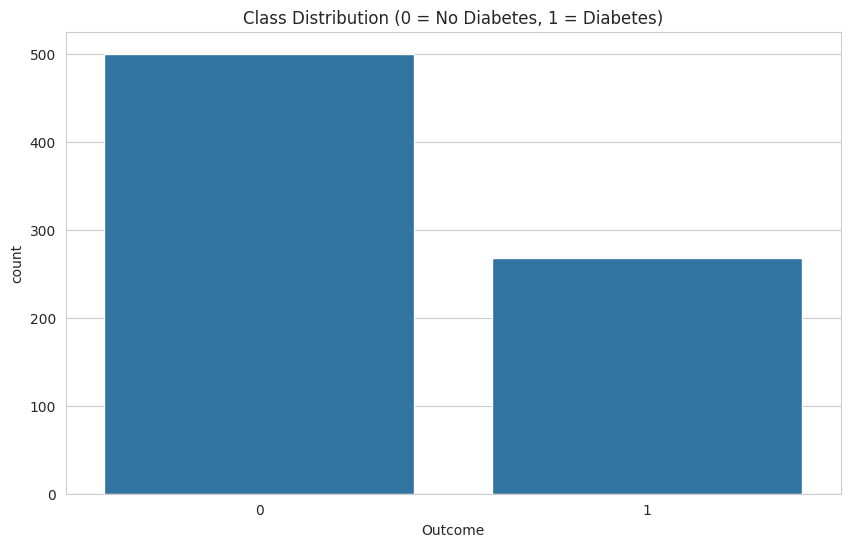

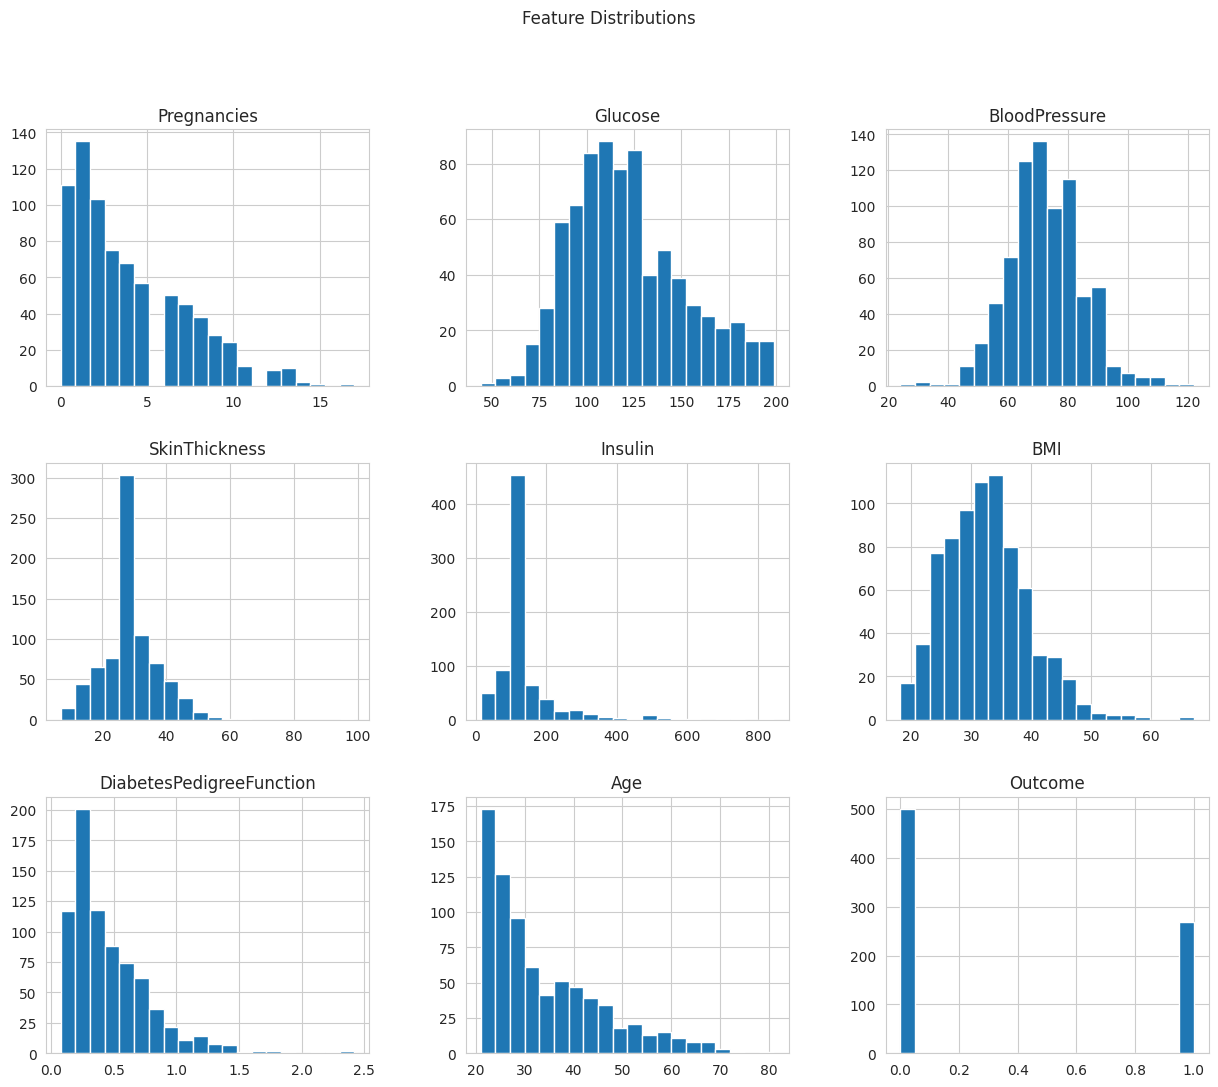

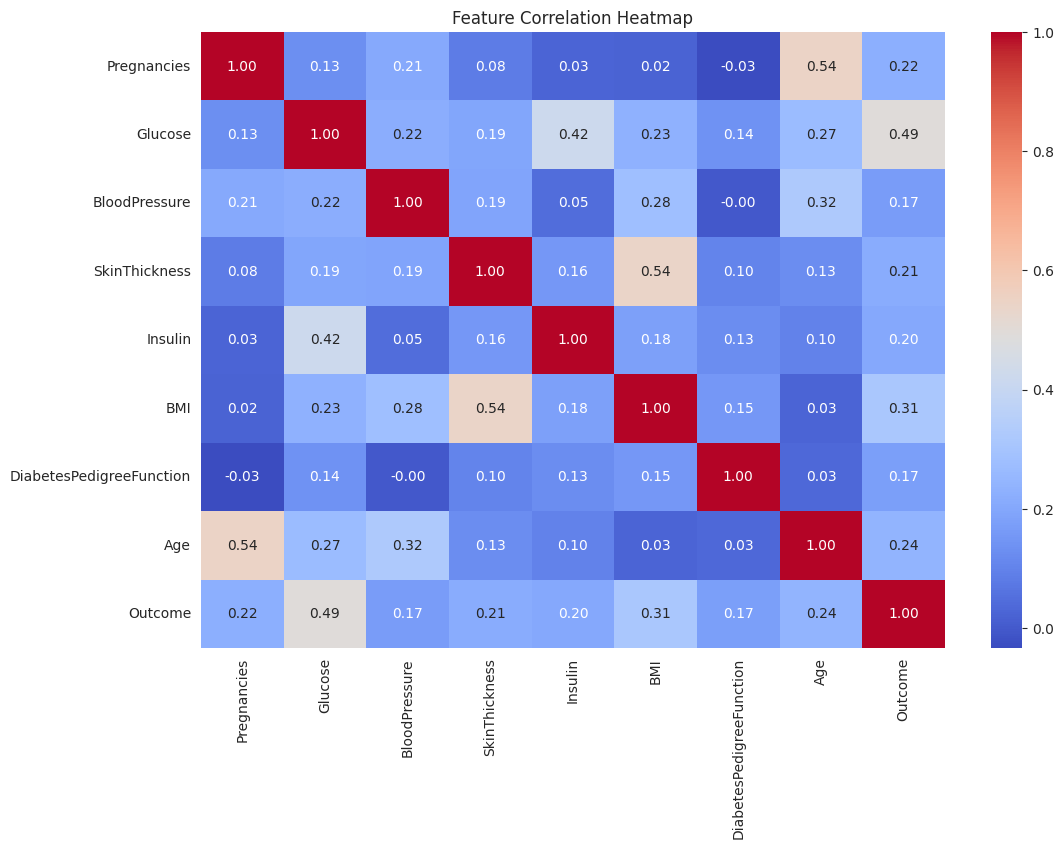

In [5]:
# Visualizations
# 1. Distribution of target
plt.figure()
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.show()

# 2. Feature distributions
df.hist(bins=20, figsize=(15, 12))
plt.suptitle('Feature Distributions')
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 4. Pairplot (optional - can take time)
# sns.pairplot(df, hue='Outcome')

In [6]:
# Split data
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (614, 8), Test set: (154, 8)


## 3 & 4. Model Selection, Development, Evaluation and Optimization

We use **RandomForestClassifier** (ensemble method, handles non-linearity, feature importance, robust to outliers).

In [7]:
# Initial model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Baseline predictions
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("Baseline Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Baseline Model Performance:
Accuracy: 0.7792
Precision: 0.7174
Recall: 0.6111
F1 Score: 0.6600
ROC-AUC: 0.8179

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Model Performance:
Accuracy: 0.7532
Precision: 0.6667
Recall: 0.5926
F1 Score: 0.6275
ROC-AUC: 0.8085


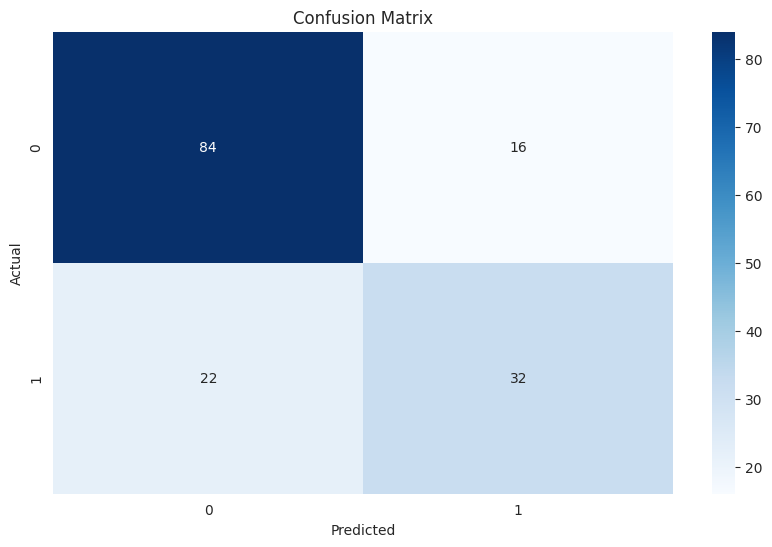

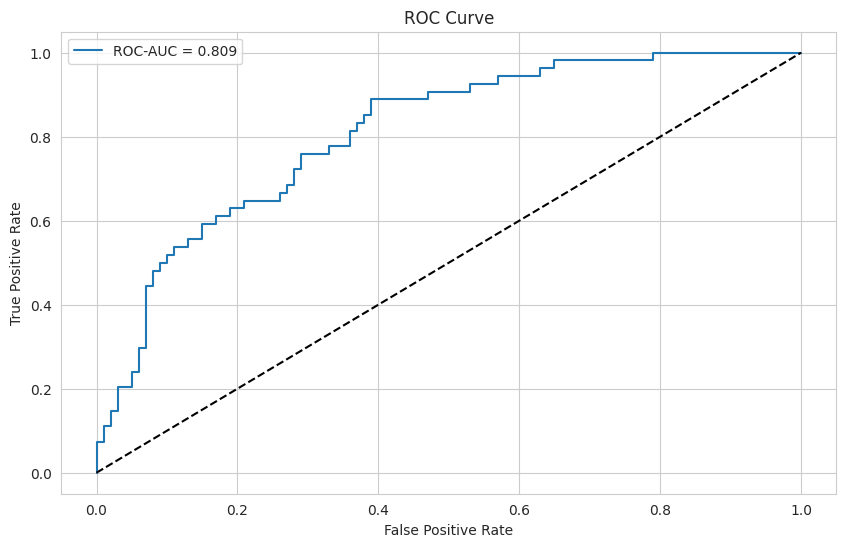

In [8]:
# Hyperparameter tuning with GridSearchCV + 5-fold CV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Final evaluation
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nTuned Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob_best):.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

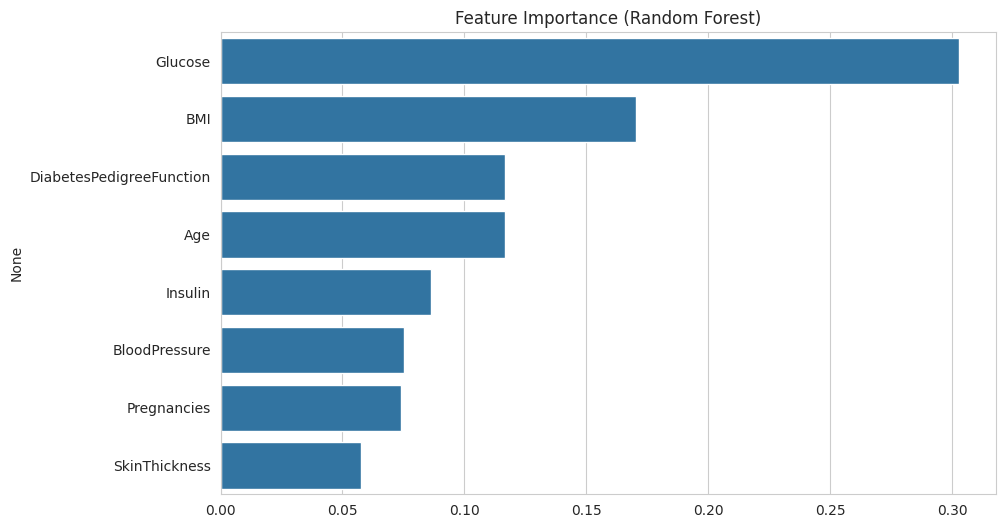

In [9]:
# Feature importance
importances = best_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure()
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.show()

In [10]:
# Save model and scaler for deployment
joblib.dump(best_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved!")

Model and scaler saved!


## 5. Model Deployment and Interactive Interface

We use **Gradio** to create a user-friendly web interface directly in Colab.  
Users can input patient data and get instant predictions with probability.

In [11]:
# Load saved model and scaler
model = joblib.load('diabetes_model.pkl')
scaler = joblib.load('scaler.pkl')

# Gradio interface
def predict_diabetes(Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI,
                     DiabetesPedigreeFunction, Age):
    input_data = np.array([[Pregnancies, Glucose, BloodPressure, SkinThickness,
                            Insulin, BMI, DiabetesPedigreeFunction, Age]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    result = "DIABETES POSITIVE (High Risk)" if prediction == 1 else "No Diabetes Detected"
    return f"{result}\nProbability: {probability:.1%}"

# Create Gradio interface
iface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Slider(0, 20, value=2, label="Pregnancies"),
        gr.Slider(0, 200, value=120, label="Glucose (mg/dL)"),
        gr.Slider(0, 150, value=70, label="Blood Pressure (mm Hg)"),
        gr.Slider(0, 100, value=25, label="Skin Thickness (mm)"),
        gr.Slider(0, 800, value=80, label="Insulin (mu U/ml)"),
        gr.Slider(0, 70, value=32, label="BMI (kg/m²)"),
        gr.Slider(0.0, 2.5, value=0.5, label="Diabetes Pedigree Function"),
        gr.Slider(20, 90, value=33, label="Age (years)")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Diabetes Prediction AI",
    description="Enter patient measurements to predict diabetes risk. Model trained on Pima Indians Diabetes Dataset.",
    examples=[
        [2, 138, 62, 35, 0, 33.6, 0.127, 47],
        [0, 84, 82, 31, 125, 38.2, 0.233, 23]
    ]
)

# Launch the interface
iface.launch(share=True)  # share=True gives a public link (valid for ~72 hours)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ecb436e2262198e35f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
